In [1]:
!pip install prophet
!pip install xgboost
!pip install statsmodels
!pip install plotly
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 1.5 MB/s  0:00:08 eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s  0:00:01m 1.1 MB/s eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]━━━ 4/5 [prophet]]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 1.3 MB/s  0:00:01m 1.2 MB/s eta 0:00:010m


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("train.csv")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [17]:
import pandas as pd

# Load Dataset
df = pd.read_csv("train.csv")

# Convert date columns
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

# Check
print(df[["Order Date", "Ship Date"]].head())
print(df.dtypes)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [19]:
# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day Name
df["Day"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Weekend or Weekday
df["Weekend"] = df["Order Date"].dt.dayofweek >= 5

In [21]:
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Weekend,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,False,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,False,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,False,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,False,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,False,Autumn


In [23]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week              0
Day               0
Quarter           0
Weekend           0
Season            0
dtype: int64

In [25]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [29]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week                     UInt32
Day                      object
Quarter                   int32
Weekend                    bool
Season                   object
dtype: object

In [31]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [33]:
weekly_sales = daily_sales.copy()

weekly_sales = weekly_sales.set_index("Order Date")

weekly_sales = weekly_sales.resample("W")["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [35]:
monthly_sales = daily_sales.copy()

monthly_sales = monthly_sales.set_index("Order Date")

monthly_sales = monthly_sales.resample("ME")["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


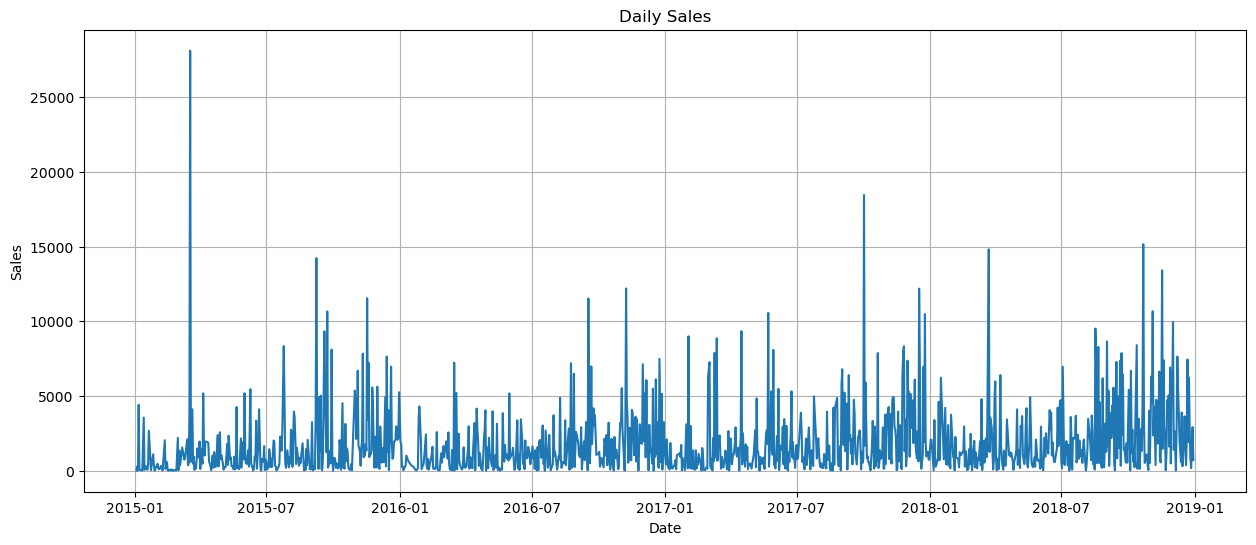

In [37]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales["Order Date"], daily_sales["Sales"])

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

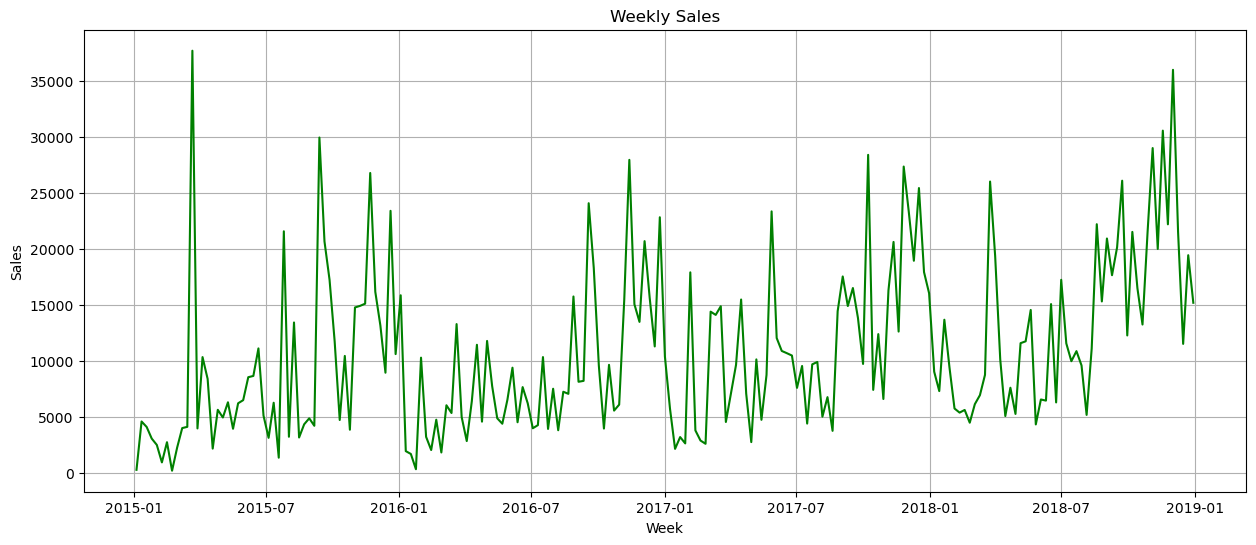

In [39]:
plt.figure(figsize=(15,6))

plt.plot(weekly_sales["Order Date"], weekly_sales["Sales"], color="green")

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

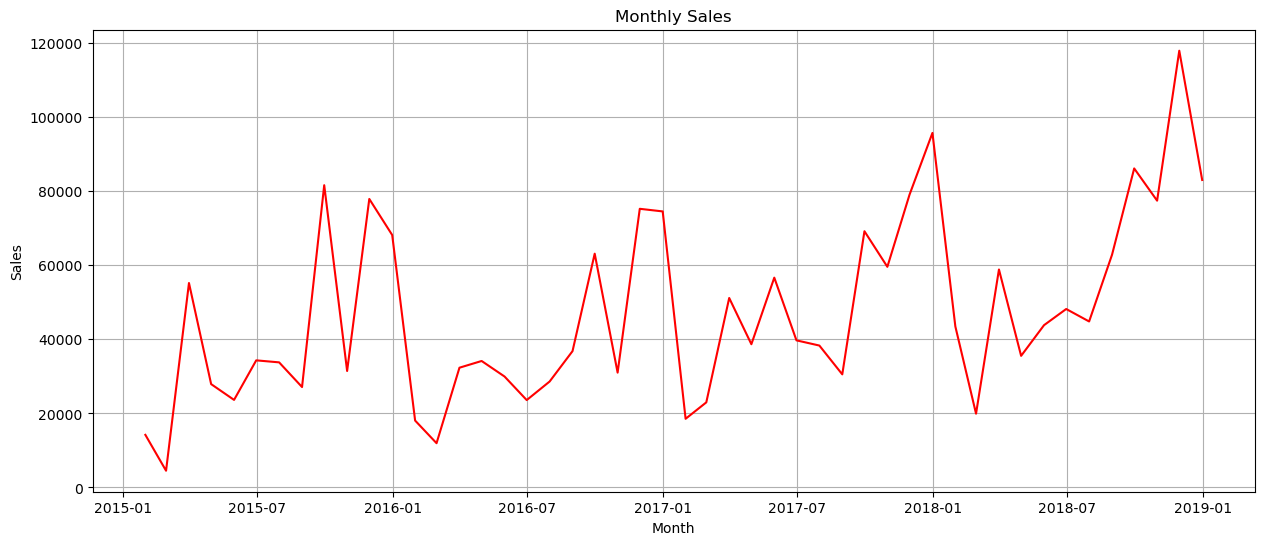

In [41]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], color="red")

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [43]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


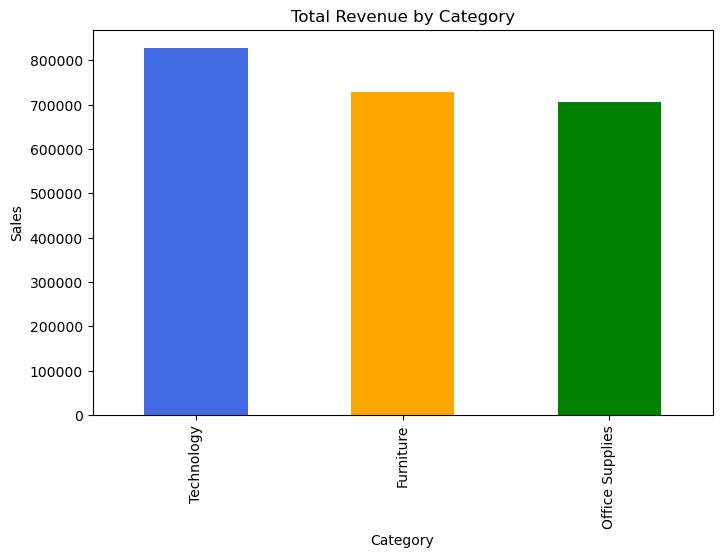

In [45]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar", color=["royalblue","orange","green"])

plt.title("Total Revenue by Category")

plt.ylabel("Sales")

plt.show()

Observation:

Technology category generates the highest total revenue followed by Furniture and Office Supplies.

In [47]:
region_sales = df.groupby(["Year","Region"])["Sales"].sum().reset_index()

region_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


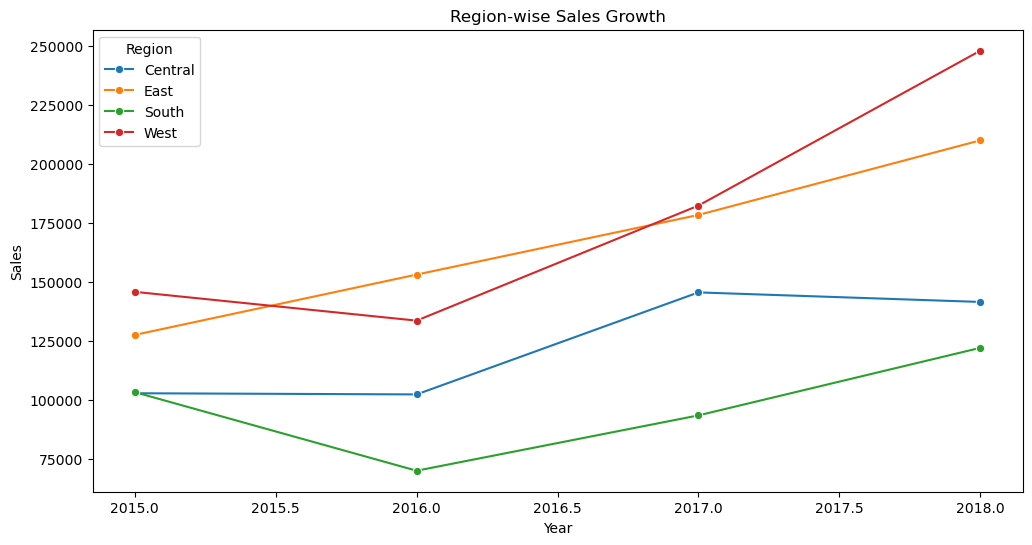

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(data=region_sales,
             x="Year",
             y="Sales",
             hue="Region",
             marker="o")

plt.title("Region-wise Sales Growth")

plt.show()

Observation:

From the graph, identify which region has the most consistent increase in sales over the four years.

In [51]:
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Shipping Time"].head()

0    3
1    3
2    4
3    7
4    7
Name: Shipping Time, dtype: int64

In [53]:
print("Average Shipping Time")

print(df["Shipping Time"].mean())

Average Shipping Time
3.9611224489795918


In [55]:
shipping_region = df.groupby("Region")["Shipping Time"].mean()

print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Time, dtype: float64


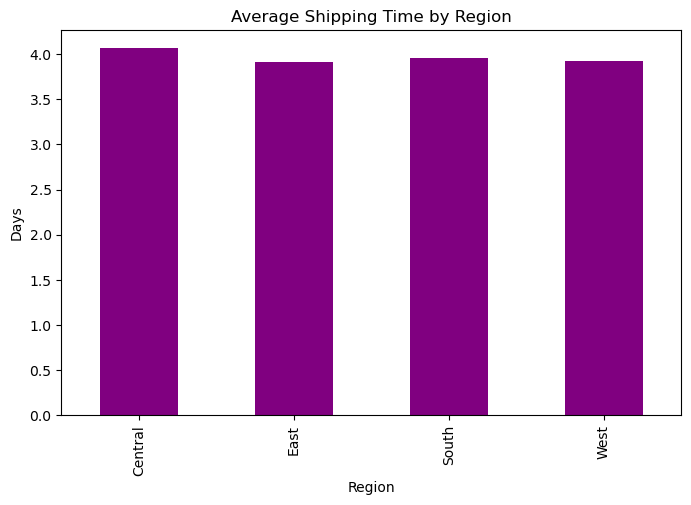

In [57]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar", color="purple")

plt.title("Average Shipping Time by Region")

plt.ylabel("Days")

plt.show()

Observation:

Compare the average shipping time for each region and mention whether shipping differs significantly.

In [59]:
monthly_pattern = df.groupby("Month Name")["Sales"].mean()

months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

monthly_pattern = monthly_pattern.reindex(months)

monthly_pattern

Month Name
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64

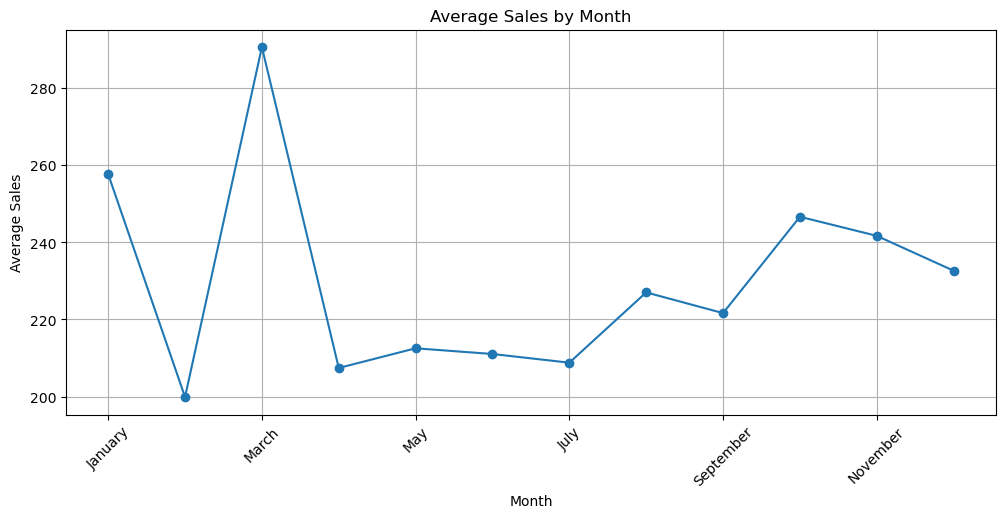

In [61]:
plt.figure(figsize=(12,5))

monthly_pattern.plot(marker="o")

plt.title("Average Sales by Month")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Observation:

Identify the months with consistently high sales.
Typically, November and December show strong sales due to holiday and festive shopping.

In [63]:
import os

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(15,6))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Monthly Sales")
plt.savefig("charts/monthly_sales.png")
plt.close()

Task 2

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [67]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [69]:
monthly_sales = monthly_sales.set_index("Order Date")

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


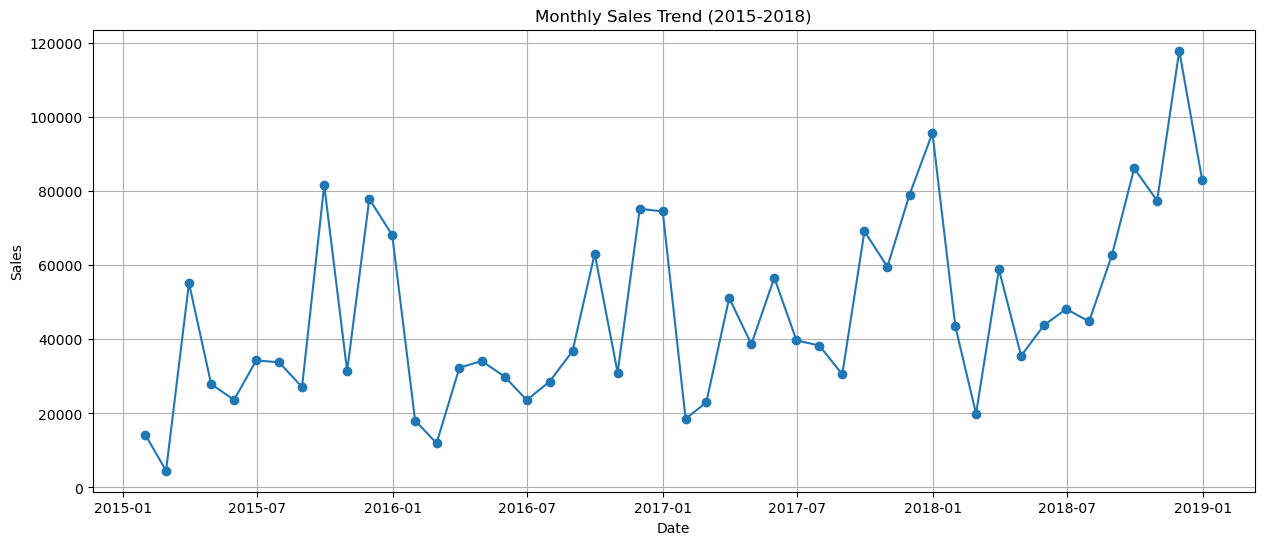

In [71]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend (2015-2018)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Observation:

The graph shows the monthly sales trend over four years. We can visually inspect whether sales are increasing over time and identify recurring seasonal peaks.

In [73]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

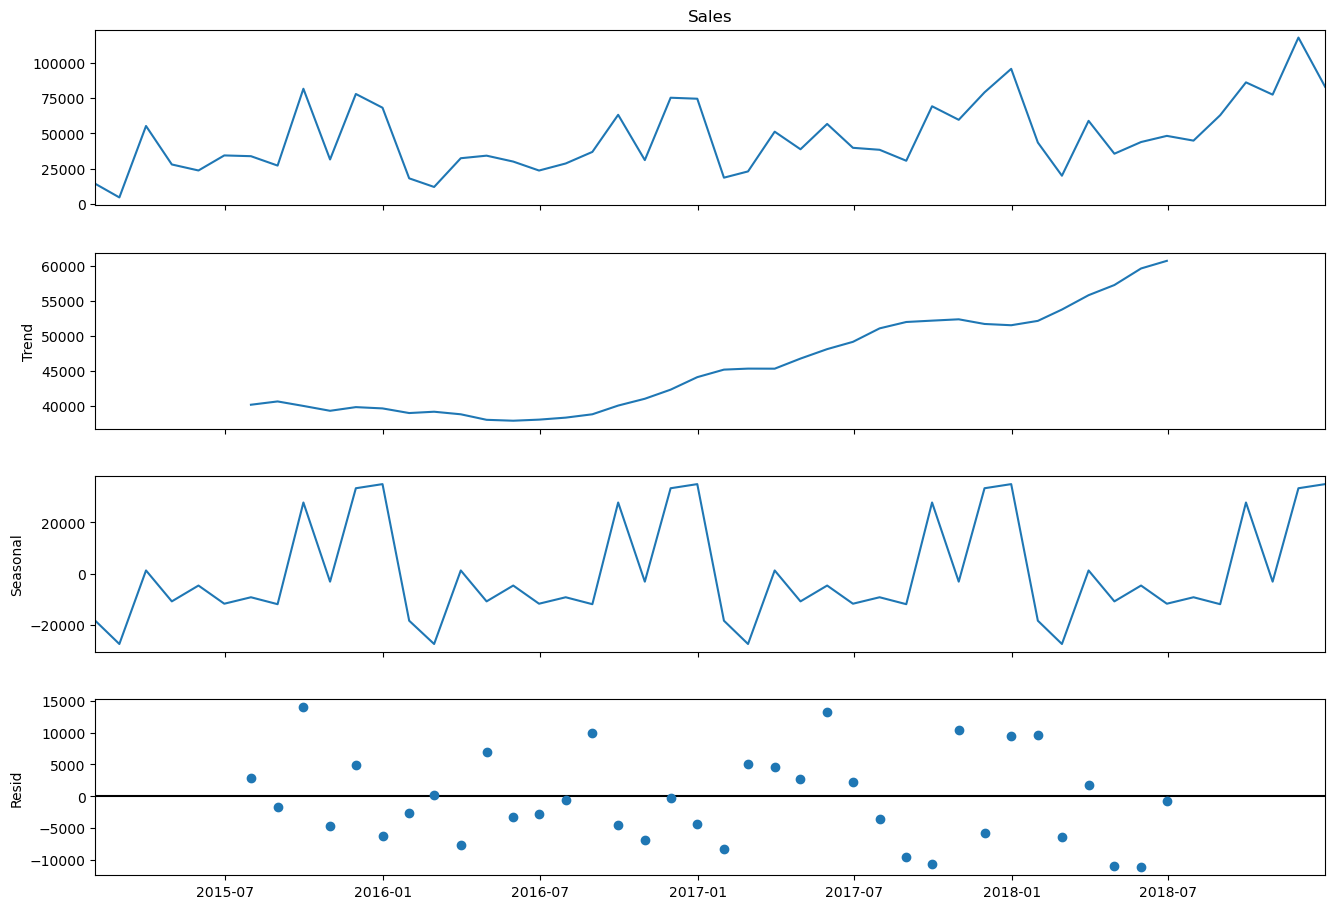

In [75]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [77]:
fig.savefig("charts/time_series_decomposition.png")

### Observations

1. Trend Component: This suggests that total sales tend to increase slowly over time.

2. Seasonal Component: This implies there is a yearly repetition in sales cycles and therefore strong seasonality.

3. Residual Component: This refers to random variations which cannot be attributed to either trend or seasonal variations.

4. Large residual values during festival months may suggest promotion efforts or some unusual events.

In [79]:
result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Number of Lags :", result[2])

print("Number of Observations :", result[3])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.41613676143077
p-value : 0.0002779103927667049
Number of Lags : 0
Number of Observations : 47

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [81]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain constant over time.

Most forecasting models, including SARIMA, assume that the data is stationary. Therefore, testing for stationarity is an important preprocessing step.

In [83]:
monthly_sales["Sales_Diff"] = monthly_sales["Sales"].diff()

monthly_sales.head()

,Sales,Sales_Diff
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [85]:
monthly_sales_diff = monthly_sales.dropna()

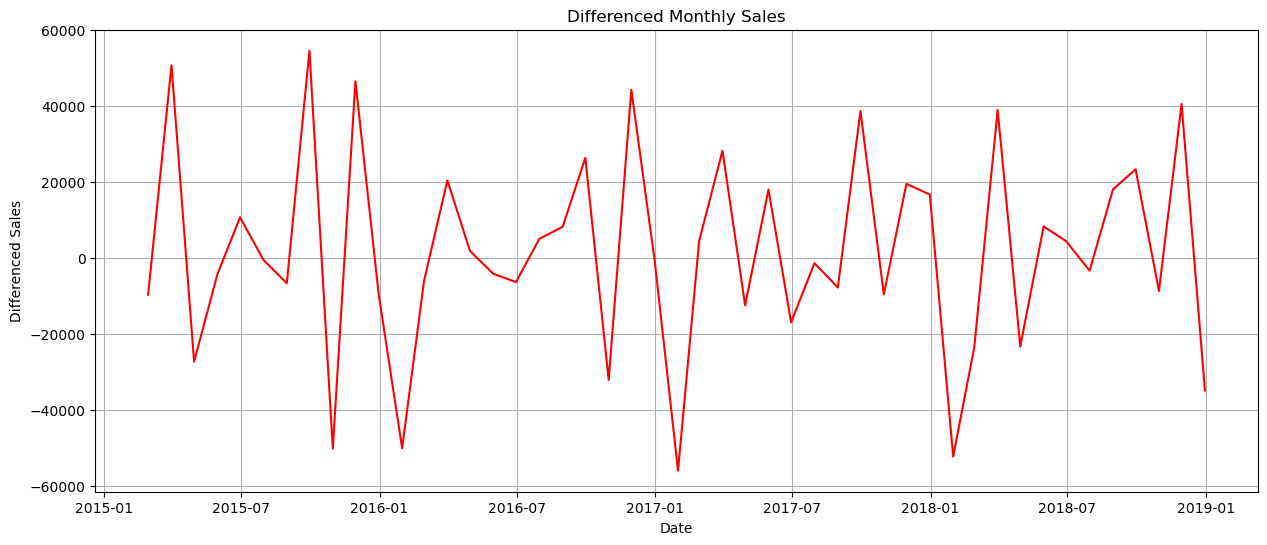

In [87]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales_diff.index,
         monthly_sales_diff["Sales_Diff"],
         color="red")

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

In [89]:
result_diff = adfuller(monthly_sales_diff["Sales_Diff"])

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

print("\nCritical Values")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.727061830353268
p-value : 3.266917547279605e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [91]:
if result_diff[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is still not stationary.")

The differenced series is stationary.


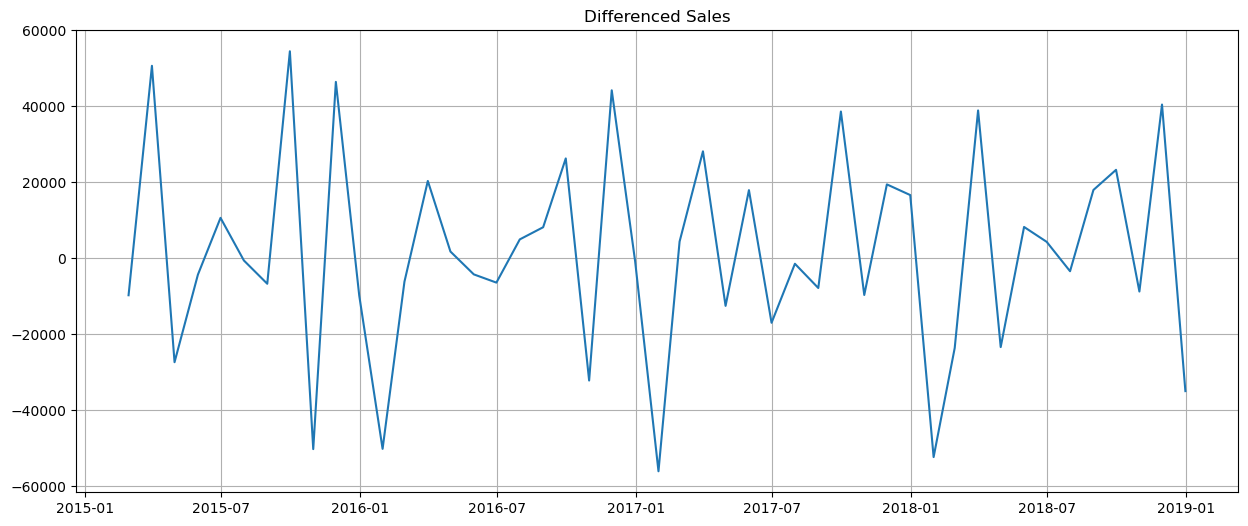

In [93]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales_diff.index,
         monthly_sales_diff["Sales_Diff"])

plt.title("Differenced Sales")

plt.grid(True)

plt.savefig("charts/differenced_sales.png")

plt.show()

## Conclusion

The time series was decomposed into different components like trend, seasonality, and residual. Decomposing helped us in understanding the underlying pattern in the sales data.

For testing the stationarity of a time series, the Augmented Dickey Fuller Test was carried out. The test revealed that the original time series was not stationary. Thus, we differentiated the time series once and again checked the stationarity of the new series through ADF test.

Now, this stationary series would be used in forecasting using models like SARIMA.

Task 3

In [95]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [97]:
monthly_sales.head()

,Sales,Sales_Diff
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [99]:
sales = monthly_sales["Sales"]

In [101]:
train = sales[:-3]

test = sales[-3:]

In [103]:
print("Training Data:", len(train))

print("Testing Data:", len(test))

Training Data: 45
Testing Data: 3


In [105]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

We selected SARIMA(1,1,1)(1,1,1,12) because:

• d=1 removes trend through differencing.
• Seasonal period is 12 because the data is monthly.
• Simple starting parameters reduce overfitting.

In [107]:
sarima_model = model.fit()

print(sarima_model.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.91185D+00    |proj g|=  6.26963D-01

At iterate    5    f=  7.74787D+00    |proj g|=  2.13186D-02

At iterate   10    f=  7.73874D+00    |proj g|=  2.97194D-02


 This problem is unconstrained.



At iterate   15    f=  7.73289D+00    |proj g|=  3.43541D-03

At iterate   20    f=  7.73287D+00    |proj g|=  3.79874D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     21     25      1     0     0   6.982D-06   7.733D+00
  F =   7.7328690210232205     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                     

In [109]:
prediction = sarima_model.predict(
    start=test.index[0],
    end=test.index[-1]
)

prediction

2018-10-31    66177.602442
2018-11-30    92049.249662
2018-12-31    99965.168699
Freq: ME, Name: predicted_mean, dtype: float64

In [111]:
comparison = pd.DataFrame({

    "Actual":test,

    "Predicted":prediction

})

comparison

,Actual,Predicted
2018-10-31,77448.1312,66177.602442
2018-11-30,117938.1550,92049.249662
2018-12-31,83030.3888,99965.168699


In [113]:
mae = mean_absolute_error(test,prediction)

print("MAE :",mae)

MAE : 18031.404665388993


In [115]:
rmse = np.sqrt(mean_squared_error(test,prediction))

print("RMSE :",rmse)

RMSE : 19009.18206514


In [117]:
mape = np.mean(np.abs((test-prediction)/test))*100

print("MAPE :",mape)

MAPE : 18.966498057287883


In [119]:
final_model = SARIMAX(

    sales,

    order=(1,1,1),

    seasonal_order=(1,1,1,12)

)

final_model = final_model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.17000D+00    |proj g|=  5.13960D-01

At iterate    5    f=  8.01497D+00    |proj g|=  2.74195D-02

At iterate   10    f=  8.00014D+00    |proj g|=  2.17266D-02

At iterate   15    f=  7.99846D+00    |proj g|=  4.31130D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     18     22      1     0     0   8.647D-06   7.998D+00
  F =   7.9984524386871074     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


In [121]:
forecast = final_model.get_forecast(steps=3)

In [123]:
forecast_values = forecast.predicted_mean

forecast_values

2019-01-31    43492.278948
2019-02-28    34805.105226
2019-03-31    69907.412177
Freq: ME, Name: predicted_mean, dtype: float64

In [125]:
confidence = forecast.conf_int()

confidence

,lower Sales,upper Sales
2019-01-31,13699.516249,73285.041646
2019-02-28,-81.437547,69691.648000
2019-03-31,32944.417386,106870.406967


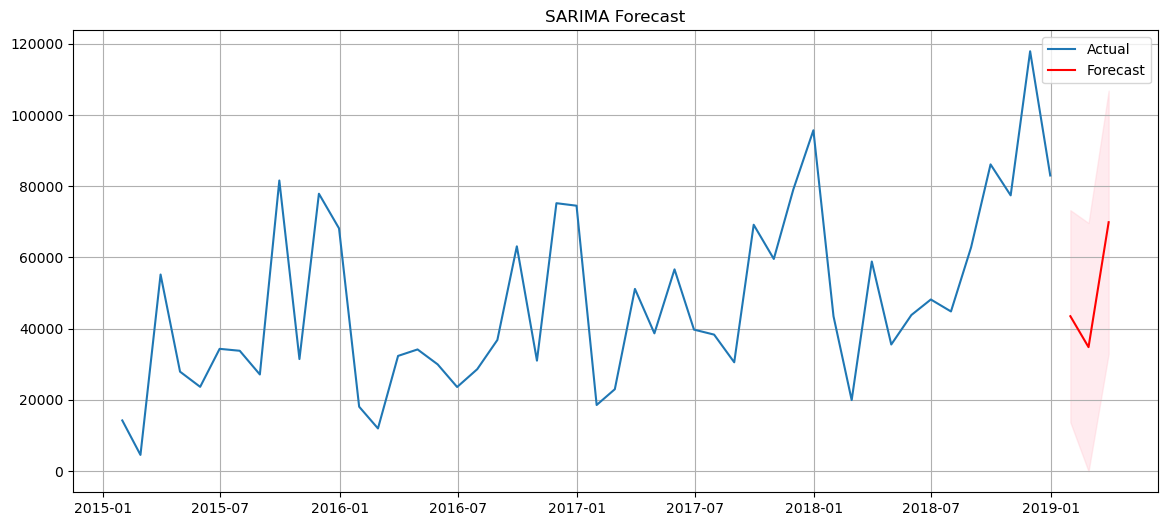

In [127]:
plt.figure(figsize=(14,6))

plt.plot(sales,label="Actual")

plt.plot(forecast_values,
         color="red",
         label="Forecast")

plt.fill_between(

    confidence.index,

    confidence.iloc[:,0],

    confidence.iloc[:,1],

    color="pink",

    alpha=0.3

)

plt.title("SARIMA Forecast")

plt.legend()

plt.grid(True)

plt.show()

In [129]:
plt.figure(figsize=(14,6))

plt.plot(sales,label="Actual")

plt.plot(forecast_values,label="Forecast")

plt.legend()

plt.savefig("charts/sarima_forecast.png")

plt.close()

In [131]:
future = pd.DataFrame({

    "Forecast Sales":forecast_values,

    "Lower CI":confidence.iloc[:,0],

    "Upper CI":confidence.iloc[:,1]

})

future

,Forecast Sales,Lower CI,Upper CI
2019-01-31,43492.278948,13699.516249,73285.041646
2019-02-28,34805.105226,-81.437547,69691.648000
2019-03-31,69907.412177,32944.417386,106870.406967


Observations

The SARIMA model accounted for both the trend and annual seasonality in the monthly sales data.

The prediction shows that sales will continue to follow the seasonal trend in the coming three months.

The confidence interval represents the possible range in which future sales will fall.

In [133]:
sarima_mae = mae

sarima_rmse = rmse

sarima_mape = mape

In [135]:
!pip install prophet

In [137]:
from prophet import Prophet

In [139]:
prophet_data = monthly_sales.reset_index()

prophet_data.head()

,Order Date,Sales,Sales_Diff
0,2015-01-31,14205.707,NaN
1,2015-02-28,4519.892,-9685.815
2,2015-03-31,55205.797,50685.905
3,2015-04-30,27906.855,-27298.942
4,2015-05-31,23644.303,-4262.552


In [141]:
prophet_data = prophet_data.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_data.head()

,ds,y,Sales_Diff
0,2015-01-31,14205.707,NaN
1,2015-02-28,4519.892,-9685.815
2,2015-03-31,55205.797,50685.905
3,2015-04-30,27906.855,-27298.942
4,2015-05-31,23644.303,-4262.552


In [143]:
train = prophet_data[:-3]

test = prophet_data[-3:]

In [145]:
print(train.shape)

print(test.shape)

(45, 3)
(3, 3)


In [147]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [149]:
model.fit(train)

20:32:55 - cmdstanpy - INFO - Chain [1] start processing
20:32:56 - cmdstanpy - INFO - Chain [1] done processing


In [151]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

In [153]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,6236.629400,22868.547310,33308.214631,33308.214631,-18874.428890,-18874.428890,-18874.428890,-18874.428890,-18874.428890,-18874.428890,0.0,0.0,0.0,14433.785740
1,2015-02-28,33767.643626,-4807.424321,10120.617215,33767.643626,33767.643626,-30869.544057,-30869.544057,-30869.544057,-30869.544057,-30869.544057,-30869.544057,0.0,0.0,0.0,2898.099569
2,2015-03-31,34276.297157,44358.022515,59792.967814,34276.297157,34276.297157,17890.437624,17890.437624,17890.437624,17890.437624,17890.437624,17890.437624,0.0,0.0,0.0,52166.734781
3,2015-04-30,34768.542509,13325.237580,29612.342581,34768.542509,34768.542509,-13661.250679,-13661.250679,-13661.250679,-13661.250679,-13661.250679,-13661.250679,0.0,0.0,0.0,21107.291830
4,2015-05-31,35277.196040,14661.312228,30569.746889,35277.196040,35277.196040,-12398.631382,-12398.631382,-12398.631382,-12398.631382,-12398.631382,-12398.631382,0.0,0.0,0.0,22878.564658


In [155]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.557363,39491.035499,55518.645461
44,2018-09-30,86613.953606,78911.994150,95078.998645
45,2018-10-31,51318.944622,42817.282681,59832.995693
46,2018-11-30,90325.653903,81977.212014,98446.563371
47,2018-12-31,90041.084686,80991.578613,97940.519958


In [157]:
predicted = forecast[["ds","yhat"]].tail(3)

predicted = predicted.reset_index(drop=True)

test = test.reset_index(drop=True)

comparison = pd.DataFrame({

    "Date":test["ds"],

    "Actual":test["y"],

    "Predicted":predicted["yhat"]

})

comparison

,Date,Actual,Predicted
0,2018-10-31,77448.1312,51318.944622
1,2018-11-30,117938.1550,90325.653903
2,2018-12-31,83030.3888,90041.084686


In [159]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(

    comparison["Actual"],

    comparison["Predicted"]

)

print("MAE :",mae)

MAE : 20250.794520289008


In [161]:
from sklearn.metrics import mean_squared_error

import numpy as np

rmse = np.sqrt(

    mean_squared_error(

        comparison["Actual"],

        comparison["Predicted"]

    )

)

print("RMSE :",rmse)

RMSE : 22318.411419276497


In [163]:
mape = np.mean(

    np.abs(

        (comparison["Actual"]-

         comparison["Predicted"])

        /comparison["Actual"]

    )

)*100

print("MAPE :",mape)

MAPE : 21.864628276964424


In [165]:
final_model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False

)

final_model.fit(prophet_data)

20:33:56 - cmdstanpy - INFO - Chain [1] start processing
20:33:56 - cmdstanpy - INFO - Chain [1] done processing


In [167]:
future = final_model.make_future_dataframe(

    periods=3,

    freq="ME"

)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [169]:
future_forecast = final_model.predict(future)

In [171]:
future_forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532188,33925.084106,51953.943224
49,2019-02-28,31248.159908,21316.094173,40104.093933
50,2019-03-31,81267.007757,71977.232450,90954.717579


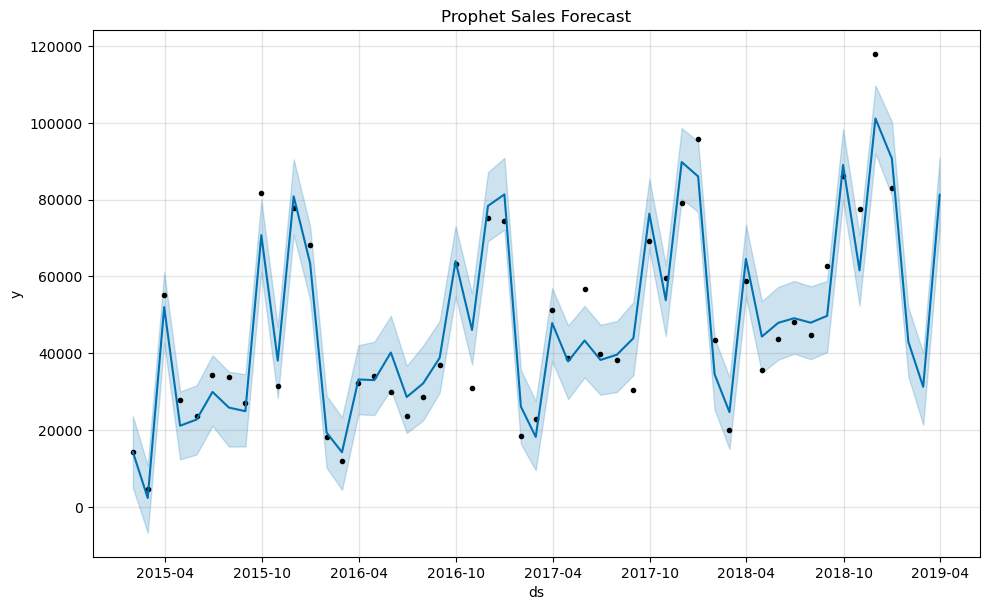

In [173]:
fig = final_model.plot(future_forecast)

plt.title("Prophet Sales Forecast")

plt.grid(True)

plt.show()

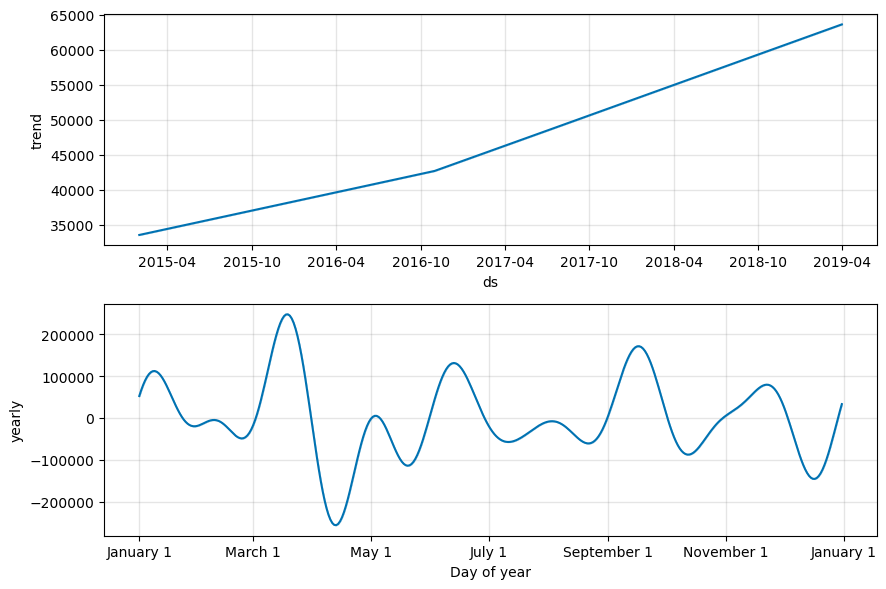

In [175]:
fig2 = final_model.plot_components(future_forecast)

plt.show()

In [177]:
fig.savefig("charts/prophet_forecast.png")

In [179]:
fig2.savefig("charts/prophet_components.png")

In [181]:
prophet_forecast = future_forecast[

    ["ds",

     "yhat",

     "yhat_lower",

     "yhat_upper"]

].tail(3)

prophet_forecast

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532188,33925.084106,51953.943224
49,2019-02-28,31248.159908,21316.094173,40104.093933
50,2019-03-31,81267.007757,71977.232450,90954.717579


### Interpretation

The Prophet model captures long-term trends and yearly seasonality in the sales data.

The forecast indicates expected sales for the next three months along with lower and upper confidence intervals. The trend component shows the overall direction of sales, while the yearly seasonality component highlights recurring annual sales patterns.

In [183]:
prophet_mae = mae

prophet_rmse = rmse

prophet_mape = mape

In [185]:
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd

In [187]:
xgb_data = monthly_sales.reset_index()

xgb_data.head()

,Order Date,Sales,Sales_Diff
0,2015-01-31,14205.707,NaN
1,2015-02-28,4519.892,-9685.815
2,2015-03-31,55205.797,50685.905
3,2015-04-30,27906.855,-27298.942
4,2015-05-31,23644.303,-4262.552


In [189]:
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

In [191]:
xgb_data["Rolling_Mean_3"] = xgb_data["Sales"].rolling(3).mean()

In [193]:
xgb_data["Month"] = xgb_data["Order Date"].dt.month

xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

xgb_data["Year"] = xgb_data["Order Date"].dt.year

In [195]:
def season(month):

    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Spring

    elif month in [6,7,8]:
        return 3      # Summer

    else:
        return 4      # Autumn

xgb_data["Season"] = xgb_data["Month"].apply(season)

In [197]:
xgb_data = xgb_data.dropna()

xgb_data.head()

,Order Date,Sales,Sales_Diff,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year,Season
3,2015-04-30,27906.8550,-27298.9420,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015,2
4,2015-05-31,23644.3030,-4262.5520,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015,2
5,2015-06-30,34322.9356,10678.6326,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015,3
6,2015-07-31,33781.5430,-541.3926,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015,3
7,2015-08-31,27117.5365,-6664.0065,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015,3


In [199]:
features = [

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Rolling_Mean_3",

    "Month",

    "Quarter",

    "Season"

]

In [201]:
X = xgb_data[features]

y = xgb_data["Sales"]

In [203]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [205]:
print(X_train.shape)

print(X_test.shape)

(42, 7)
(3, 7)


In [207]:
model = XGBRegressor(

    n_estimators=100,

    learning_rate=0.05,

    max_depth=3,

    random_state=42
)

In [209]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [211]:
prediction = model.predict(X_test)

In [213]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":prediction

})

comparison

,Actual,Predicted
0,77448.1312,84795.828125
1,117938.1550,85497.078125
2,83030.3888,85731.578125


In [215]:
mae = mean_absolute_error(y_test,prediction)

print("MAE :",mae)

MAE : 14163.321041666664


In [217]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        prediction

    )

)

print("RMSE :",rmse)

RMSE : 19267.49025933587


In [219]:
mape = np.mean(

    np.abs(

        (y_test-prediction)

        /y_test

    )

)*100

print("MAPE :",mape)

MAPE : 13.415785780855515


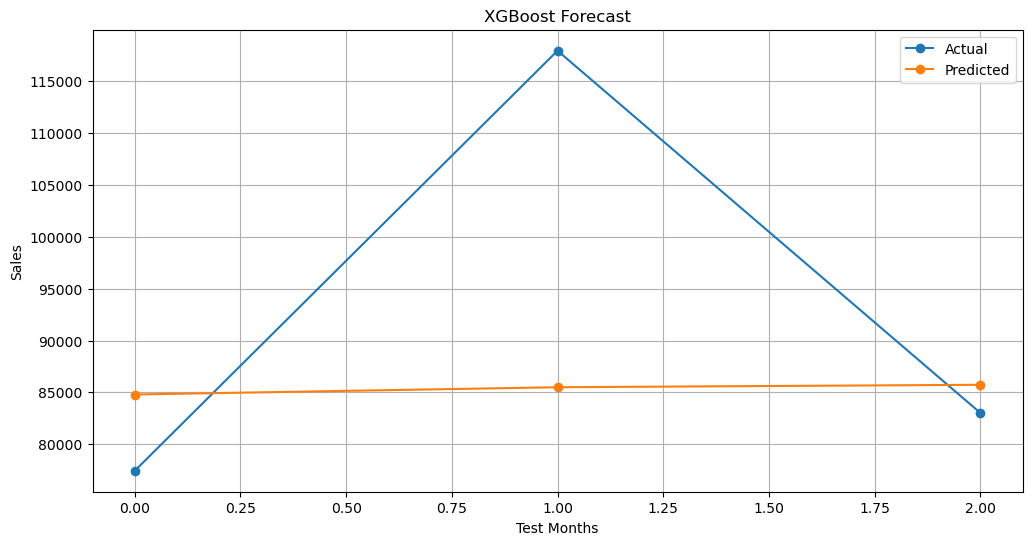

In [221]:
plt.figure(figsize=(12,6))

plt.plot(

    y_test.values,

    marker="o",

    label="Actual"

)

plt.plot(

    prediction,

    marker="o",

    label="Predicted"

)

plt.title("XGBoost Forecast")

plt.xlabel("Test Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [223]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,label="Actual")

plt.plot(prediction,label="Predicted")

plt.legend()

plt.savefig("charts/xgboost_forecast.png")

plt.close()

In [225]:
final_model = XGBRegressor(

    n_estimators=100,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

final_model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [227]:
future_predictions = []

future_data = xgb_data.copy()

In [229]:
last = future_data.iloc[-1]

new_row = pd.DataFrame({

    "Lag_1":[last["Sales"]],

    "Lag_2":[last["Lag_1"]],

    "Lag_3":[last["Lag_2"]],

    "Rolling_Mean_3":[
        np.mean([
            last["Sales"],
            last["Lag_1"],
            last["Lag_2"]
        ])
    ],

    "Month":[1],

    "Quarter":[1],

    "Season":[1]

})

pred1 = final_model.predict(new_row)[0]

future_predictions.append(pred1)

In [231]:
new_row = pd.DataFrame({

    "Lag_1":[pred1],

    "Lag_2":[last["Sales"]],

    "Lag_3":[last["Lag_1"]],

    "Rolling_Mean_3":[
        np.mean([
            pred1,
            last["Sales"],
            last["Lag_1"]
        ])
    ],

    "Month":[2],

    "Quarter":[1],

    "Season":[1]

})

pred2 = final_model.predict(new_row)[0]

future_predictions.append(pred2)

In [233]:
new_row = pd.DataFrame({

    "Lag_1":[pred2],

    "Lag_2":[pred1],

    "Lag_3":[last["Sales"]],

    "Rolling_Mean_3":[
        np.mean([
            pred2,
            pred1,
            last["Sales"]
        ])
    ],

    "Month":[3],

    "Quarter":[1],

    "Season":[2]

})

pred3 = final_model.predict(new_row)[0]

future_predictions.append(pred3)

In [235]:
forecast = pd.DataFrame({

    "Month":[

        "Month 1",

        "Month 2",

        "Month 3"

    ],

    "Forecast Sales":future_predictions

})

forecast

,Month,Forecast Sales
0,Month 1,53656.347656
1,Month 2,33013.281250
2,Month 3,59154.753906


In [237]:
xgb_mae = mae

xgb_rmse = rmse

xgb_mape = mape

## Interpretation

The XGBoost model uses historical sales (lag features), rolling averages, and time-based variables to predict future demand.

Unlike SARIMA and Prophet, XGBoost is a machine learning model that can capture complex nonlinear relationships in the data. Its performance is evaluated using MAE, RMSE, and MAPE, and the forecasts for the next three months are generated recursively using previous predictions.

In [239]:
print("SARIMA")
print("MAE :", sarima_mae)
print("RMSE :", sarima_rmse)
print("MAPE :", sarima_mape)

print("\nProphet")
print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

print("\nXGBoost")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)

SARIMA
MAE : 18031.404665388993
RMSE : 19009.18206514
MAPE : 18.966498057287883

Prophet
MAE : 20250.794520289008
RMSE : 22318.411419276497
MAPE : 21.864628276964424

XGBoost
MAE : 14163.321041666664
RMSE : 19267.49025933587
MAPE : 13.415785780855515


In [241]:
sarima_forecast = forecast_values.values

In [243]:
prophet_forecast_values = prophet_forecast["yhat"].values

In [245]:
xgb_forecast = future_predictions

In [247]:
comparison_table = pd.DataFrame({

    "Model":[

        "SARIMA",

        "Prophet",

        "XGBoost"

    ],

    "MAE":[

        sarima_mae,

        prophet_mae,

        xgb_mae

    ],

    "RMSE":[

        sarima_rmse,

        prophet_rmse,

        xgb_rmse

    ],

    "MAPE":[

        sarima_mape,

        prophet_mape,

        xgb_mape

    ],

    "Forecast Month 1":[

        sarima_forecast[0],

        prophet_forecast_values[0],

        xgb_forecast[0]

    ],

    "Forecast Month 2":[

        sarima_forecast[1],

        prophet_forecast_values[1],

        xgb_forecast[1]

    ],

    "Forecast Month 3":[

        sarima_forecast[2],

        prophet_forecast_values[2],

        xgb_forecast[2]

    ]

})

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404665,19009.182065,18.966498,43492.278948,34805.105226,69907.412177
1,Prophet,20250.794520,22318.411419,21.864628,42990.532188,31248.159908,81267.007757
2,XGBoost,14163.321042,19267.490259,13.415786,53656.347656,33013.281250,59154.753906


In [249]:
comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,43492.28,34805.11,69907.41
1,Prophet,20250.79,22318.41,21.86,42990.53,31248.16,81267.01
2,XGBoost,14163.32,19267.49,13.42,53656.35,33013.28,59154.75


In [251]:
best_model = comparison_table.loc[
    comparison_table["MAE"].idxmin()
]

best_model

Model                XGBoost
MAE                 14163.32
RMSE                19267.49
MAPE                   13.42
Forecast Month 1    53656.35
Forecast Month 2    33013.28
Forecast Month 3    59154.75
Name: 2, dtype: object

In [253]:
print("Best Forecasting Model")

print(best_model["Model"])

Best Forecasting Model
XGBoost


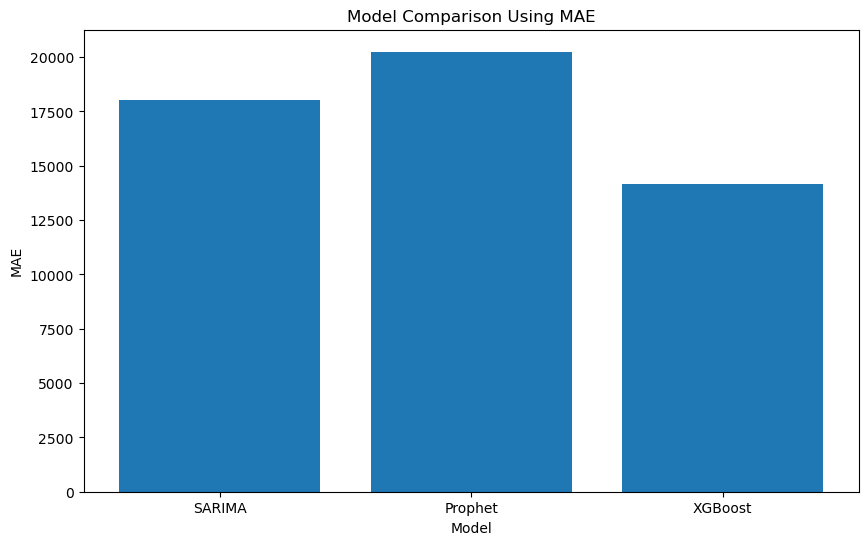

In [255]:
plt.figure(figsize=(10,6))

plt.bar(

    comparison_table["Model"],

    comparison_table["MAE"]

)

plt.title("Model Comparison Using MAE")

plt.xlabel("Model")

plt.ylabel("MAE")

plt.show()

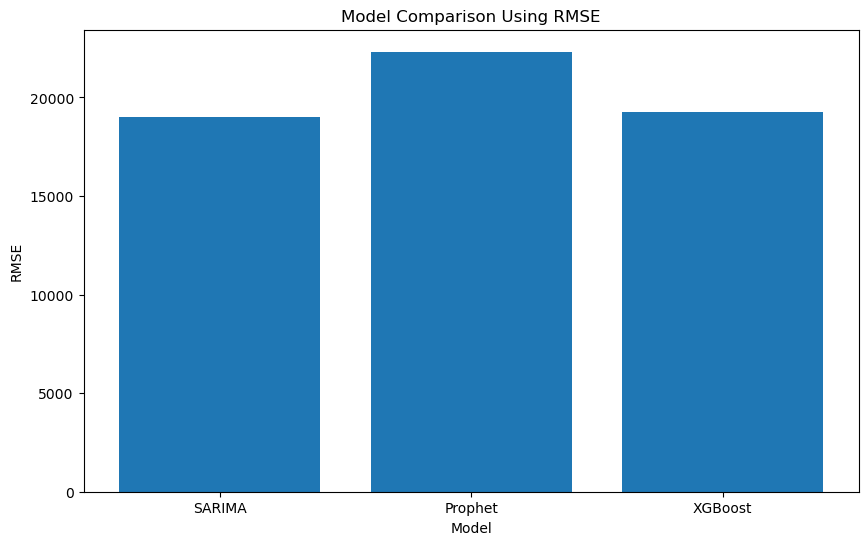

In [257]:
plt.figure(figsize=(10,6))

plt.bar(

    comparison_table["Model"],

    comparison_table["RMSE"]

)

plt.title("Model Comparison Using RMSE")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.show()

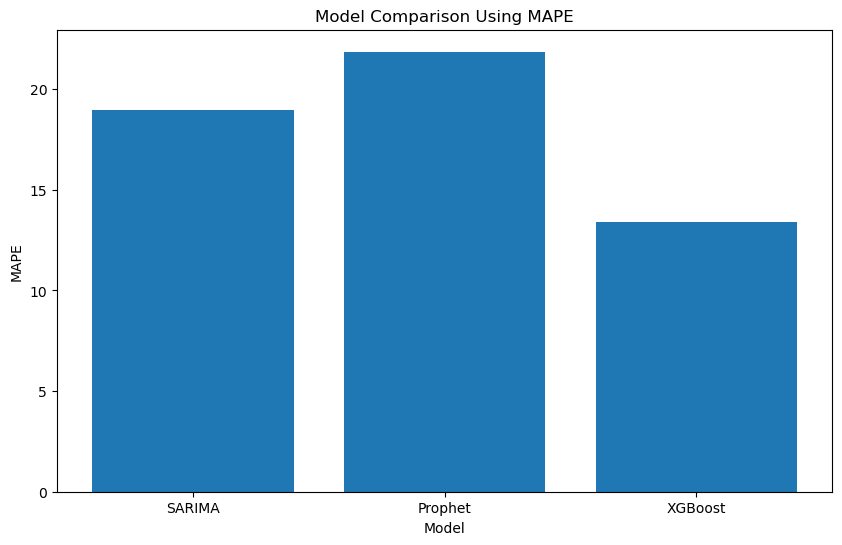

In [259]:
plt.figure(figsize=(10,6))

plt.bar(

    comparison_table["Model"],

    comparison_table["MAPE"]

)

plt.title("Model Comparison Using MAPE")

plt.xlabel("Model")

plt.ylabel("MAPE")

plt.show()

In [261]:
comparison_table.to_csv(
    "Model_Comparison.csv",
    index=False
)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,43492.28,34805.11,69907.41
1,Prophet,20250.79,22318.41,21.86,42990.53,31248.16,81267.01
2,XGBoost,14163.32,19267.49,13.42,53656.35,33013.28,59154.75


Task 4

In [267]:
furniture = df[df["Category"] == "Furniture"]

furniture_monthly = furniture.groupby("Order Date")["Sales"].sum()

furniture_monthly = furniture_monthly.resample("ME").sum()

# Technology
technology = df[df["Category"] == "Technology"]

technology_monthly = technology.groupby("Order Date")["Sales"].sum()

technology_monthly = technology_monthly.resample("ME").sum()

office = df[df["Category"] == "Office Supplies"]

office_monthly = office.groupby("Order Date")["Sales"].sum()

office_monthly = office_monthly.resample("ME").sum()

In [269]:
west = df[df["Region"] == "West"]

west_monthly = west.groupby("Order Date")["Sales"].sum()

west_monthly = west_monthly.resample("ME").sum()

east = df[df["Region"] == "East"]

east_monthly = east.groupby("Order Date")["Sales"].sum()

east_monthly = east_monthly.resample("ME").sum()

In [271]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_sales(series):

    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=3)

    return forecast

In [273]:
furniture_forecast = forecast_sales(furniture_monthly)

technology_forecast = forecast_sales(technology_monthly)

office_forecast = forecast_sales(office_monthly)

west_forecast = forecast_sales(west_monthly)

east_forecast = forecast_sales(east_monthly)

In [275]:
print("Furniture")
print(furniture_forecast)

print("\nTechnology")
print(technology_forecast)

print("\nOffice Supplies")
print(office_forecast)

print("\nWest")
print(west_forecast)

print("\nEast")
print(east_forecast)

Furniture
2019-01-31     8183.304594
2019-02-28     9204.587134
2019-03-31    16774.204339
Freq: ME, Name: predicted_mean, dtype: float64

Technology
2019-01-31    18891.368444
2019-02-28    19408.018028
2019-03-31    33497.035239
Freq: ME, Name: predicted_mean, dtype: float64

Office Supplies
2019-01-31    17971.454222
2019-02-28    14518.928745
2019-03-31    22941.187472
Freq: ME, Name: predicted_mean, dtype: float64

West
2019-01-31    13126.550921
2019-02-28    12187.364091
2019-03-31    29001.185119
Freq: ME, Name: predicted_mean, dtype: float64

East
2019-01-31    12701.878780
2019-02-28     6486.114806
2019-03-31    13938.823240
Freq: ME, Name: predicted_mean, dtype: float64


In [277]:
forecast_table = pd.DataFrame({

    "Month 1":[
        furniture_forecast.iloc[0],
        technology_forecast.iloc[0],
        office_forecast.iloc[0],
        west_forecast.iloc[0],
        east_forecast.iloc[0]
    ],

    "Month 2":[
        furniture_forecast.iloc[1],
        technology_forecast.iloc[1],
        office_forecast.iloc[1],
        west_forecast.iloc[1],
        east_forecast.iloc[1]
    ],

    "Month 3":[
        furniture_forecast.iloc[2],
        technology_forecast.iloc[2],
        office_forecast.iloc[2],
        west_forecast.iloc[2],
        east_forecast.iloc[2]
    ]

},

index=[

    "Furniture",

    "Technology",

    "Office Supplies",

    "West",

    "East"

])

forecast_table

,Month 1,Month 2,Month 3
Furniture,8183.304594,9204.587134,16774.204339
Technology,18891.368444,19408.018028,33497.035239
Office Supplies,17971.454222,14518.928745,22941.187472
West,13126.550921,12187.364091,29001.185119
East,12701.878780,6486.114806,13938.823240


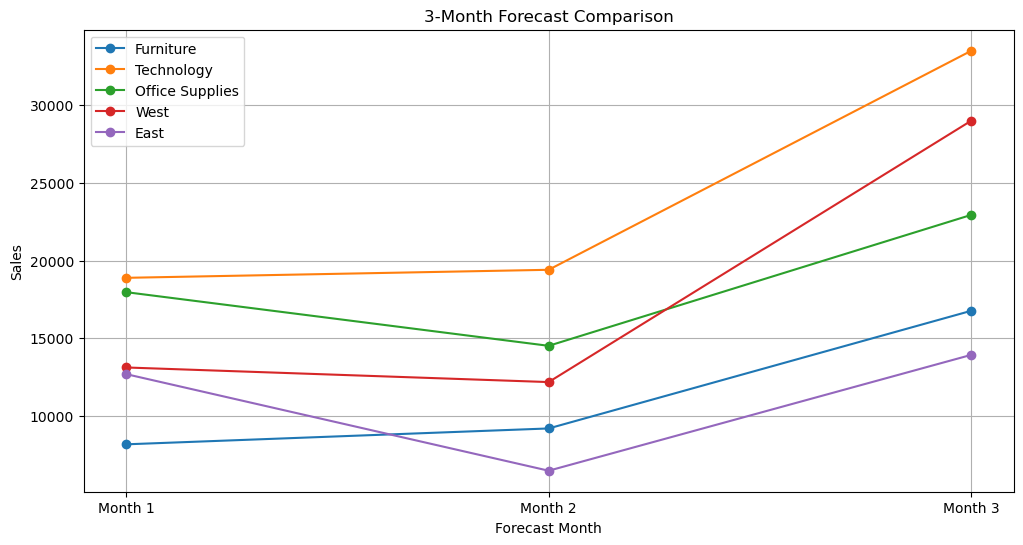

In [279]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast.values,
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast.values,
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast.values,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast.values,
    marker="o",
    label="West"
)

plt.plot(
    east_forecast.values,
    marker="o",
    label="East"
)

plt.title("3-Month Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.xticks([0,1,2],["Month 1","Month 2","Month 3"])

plt.legend()

plt.grid(True)

plt.show()

In [281]:
plt.figure(figsize=(12,6))

plt.plot(furniture_forecast.values, label="Furniture")
plt.plot(technology_forecast.values, label="Technology")
plt.plot(office_forecast.values, label="Office Supplies")
plt.plot(west_forecast.values, label="West")
plt.plot(east_forecast.values, label="East")

plt.legend()

plt.savefig("charts/category_region_forecast.png")

plt.close()

In [283]:
growth = forecast_table["Month 3"]

highest = growth.idxmax()

print("Highest Expected Growth:")

print(highest)

Highest Expected Growth:
Technology


In [285]:
forecast_table.to_csv("Category_Region_Forecast.csv")

Task 5

In [287]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

In [289]:
weekly_sales = df.groupby("Order Date")["Sales"].sum()

weekly_sales = weekly_sales.resample("W").sum()

weekly_sales = weekly_sales.reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [291]:
weekly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  209 non-null    datetime64[ns]
 1   Sales       209 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.4 KB


In [293]:
iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Anomaly"] = iso.fit_predict(

    weekly_sales[["Sales"]]

)

In [295]:
weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [297]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [299]:
print("Total Anomalies Found :")

print(len(anomalies))

Total Anomalies Found :
11


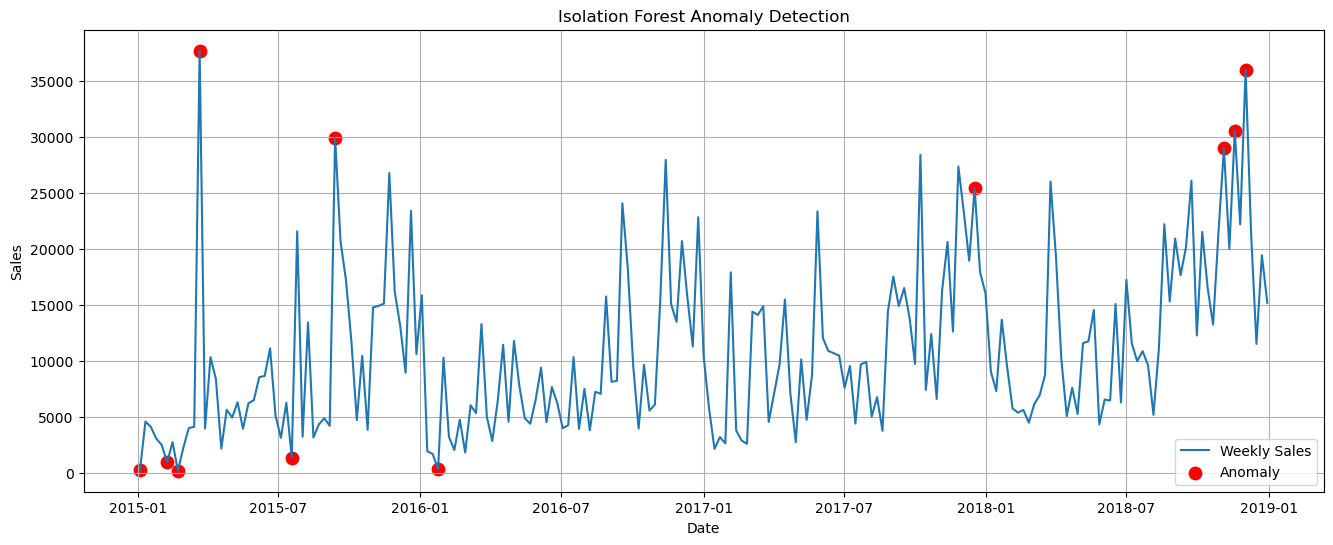

In [301]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red",

    s=80,

    label="Anomaly"

)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [303]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"]

)

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red"

)

plt.savefig("charts/isolation_forest.png")

plt.close()

In [305]:
anomalies[["Order Date","Sales"]]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [307]:
weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(4).mean()

weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(4).std()

In [309]:
weekly_sales["Z-Score"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["Rolling Mean"]

)/weekly_sales["Rolling Std"]

In [311]:
weekly_sales["Z_Anomaly"] = np.where(

    abs(weekly_sales["Z-Score"]) > 2,

    1,

    0

)

In [313]:
z_anomalies = weekly_sales[

    weekly_sales["Z_Anomaly"]==1

]

z_anomalies

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly


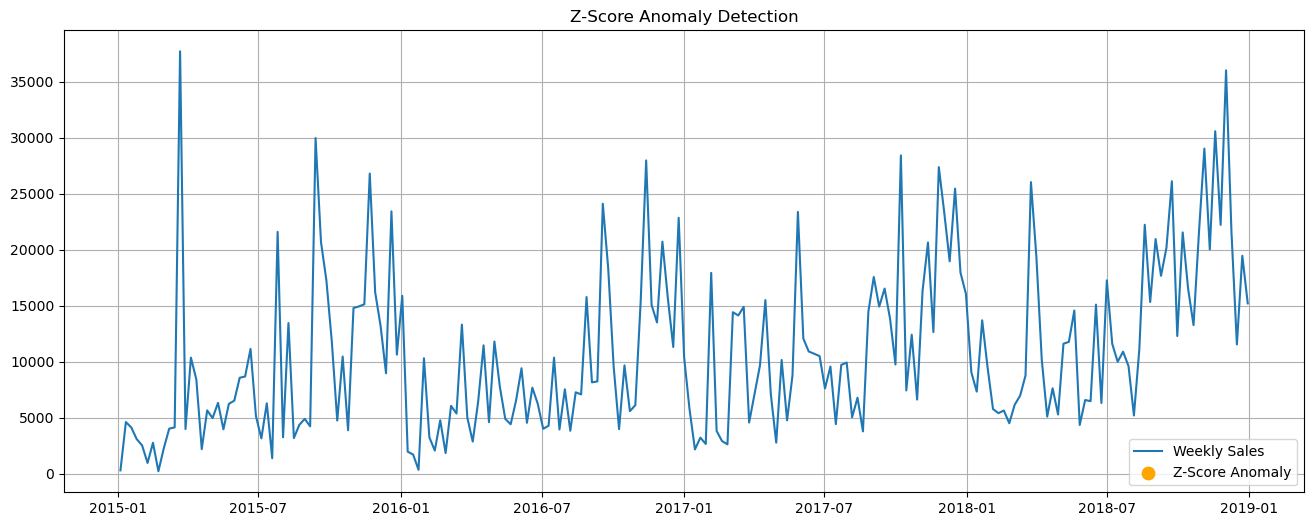

In [315]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="orange",

    s=80,

    label="Z-Score Anomaly"

)

plt.title("Z-Score Anomaly Detection")

plt.legend()

plt.grid(True)

plt.show()

In [317]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"]

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="orange"

)

plt.savefig("charts/zscore_anomaly.png")

plt.close()

In [319]:
print("Isolation Forest Anomalies")

print(len(anomalies))

print()

print("Z-Score Anomalies")

print(len(z_anomalies))

Isolation Forest Anomalies
11

Z-Score Anomalies
0


In [321]:
common = pd.merge(

    anomalies,

    z_anomalies,

    on="Order Date"

)

print(common[["Order Date"]])

Empty DataFrame
Columns: [Order Date]
Index: []


In [323]:
comparison = pd.DataFrame({

    "Method":[

        "Isolation Forest",

        "Z-Score"

    ],

    "No. of Anomalies":[

        len(anomalies),

        len(z_anomalies)

    ]

})

comparison

,Method,No. of Anomalies
0,Isolation Forest,11
1,Z-Score,0


In [325]:
comparison.to_csv(

    "Anomaly_Comparison.csv",

    index=False

)

## Potential Business Explanations for Identified Anomalies

• Sudden peaks in sales can arise from festivities such as Diwali, Christmas, or Black Friday sales.

• Declines in sales in a particular week may be due to lack of stock, low inventory, or low customer demand.

• Some anomalies may be linked to marketing drives and discounts being offered.

• Other sudden declines may result from logistical problems.

## Comparison of Isolation Forest and Z-Score

In Isolation Forest, machine learning is employed to find out the anomalies according to the patterns of data.

Z-Score is used to detect the points that are more than two standard deviations away from the moving average.

There are some anomalies that are picked up by both the approaches but there are some anomalies that are distinct for each approach.

In [327]:
anomalies.sort_values(

    "Sales",

    ascending=False

).head()

,Order Date,Sales,Anomaly
11,2015-03-22,37703.665,-1
204,2018-12-02,35998.900,-1
202,2018-11-18,30572.447,-1
36,2015-09-13,29959.137,-1
200,2018-11-04,29017.467,-1


In [329]:
anomalies.to_csv(

    "Detected_Anomalies.csv",

    index=False

)

Task 6

In [361]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [363]:
total_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()

total_sales.columns = [

    "Sub-Category",

    "Total Sales"

]

total_sales.head()

,Sub-Category,Total Sales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987


In [365]:
average_order = df.groupby(

    "Sub-Category"

)["Sales"].mean().reset_index()

average_order.columns = [

    "Sub-Category",

    "Average Order Value"

]

average_order.head()

,Sub-Category,Average Order Value
0,Accessories,217.178175
1,Appliances,227.926804
2,Art,34.019631
3,Binders,134.067550
4,Bookcases,503.598224


In [367]:
monthly_sales = df.groupby(

    ["Sub-Category","Year","Month"]

)["Sales"].sum().reset_index()

monthly_sales.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


In [369]:
sales_volatility = monthly_sales.groupby(

    "Sub-Category"

)["Sales"].std().reset_index()

sales_volatility.columns = [

    "Sub-Category",

    "Sales Volatility"

]

sales_volatility.head()

,Sub-Category,Sales Volatility
0,Accessories,2579.994809
1,Appliances,1821.621539
2,Art,330.488343
3,Binders,3848.223648
4,Bookcases,2220.405080


In [371]:
growth = monthly_sales.groupby("Sub-Category").agg(

    First=("Sales","first"),

    Last=("Sales","last")

).reset_index()

growth["Growth Rate"] = (

    (growth["Last"]-

     growth["First"])

    /

    growth["First"]

)*100

growth = growth[

    [

        "Sub-Category",

        "Growth Rate"

    ]

]

growth.head()

,Sub-Category,Growth Rate
0,Accessories,502.615806
1,Appliances,1977.573101
2,Art,387.190237
3,Binders,484.392296
4,Bookcases,261.772161


In [373]:
product_data = total_sales.merge(

    average_order,

    on="Sub-Category"

)

product_data = product_data.merge(

    sales_volatility,

    on="Sub-Category"

)

product_data = product_data.merge(

    growth,

    on="Sub-Category"

)

product_data.head()

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate
0,Accessories,164186.7000,217.178175,2579.994809,502.615806
1,Appliances,104618.4030,227.926804,1821.621539,1977.573101
2,Art,26705.4100,34.019631,330.488343,387.190237
3,Binders,200028.7850,134.067550,3848.223648,484.392296
4,Bookcases,113813.1987,503.598224,2220.405080,261.772161


In [375]:
product_data.fillna(0,inplace=True)

In [377]:
product_data

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate
0,Accessories,164186.7000,217.178175,2579.994809,502.615806
1,Appliances,104618.4030,227.926804,1821.621539,1977.573101
2,Art,26705.4100,34.019631,330.488343,387.190237
3,Binders,200028.7850,134.067550,3848.223648,484.392296
4,Bookcases,113813.1987,503.598224,2220.405080,261.772161
5,Chairs,322822.7310,531.833165,4407.232960,257.390883
6,Copiers,146248.0940,2215.880212,5500.774391,122.668129
7,Envelopes,16128.0460,65.032444,228.218688,113.449269
8,Fasteners,3001.9600,14.027850,48.742229,446.375321
9,Furnishings,89212.0180,95.823865,1360.017867,491.629693


In [379]:
X = product_data[

    [

        "Total Sales",

        "Average Order Value",

        "Sales Volatility",

        "Growth Rate"

    ]

]

In [381]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [383]:
wcss = []

for i in range(1,11):

    model = KMeans(

        n_clusters=i,

        random_state=42,

        n_init=10

    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

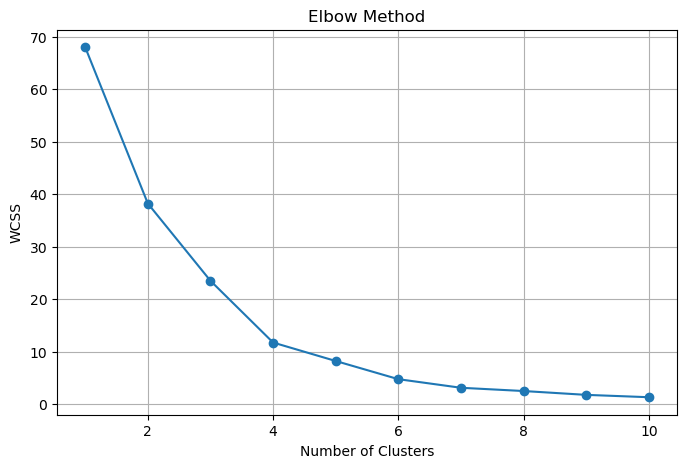

In [385]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,11),

    wcss,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [387]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

product_data["Cluster"] = kmeans.fit_predict(

    X_scaled

)

In [389]:
product_data

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
0,Accessories,164186.7000,217.178175,2579.994809,502.615806,0
1,Appliances,104618.4030,227.926804,1821.621539,1977.573101,2
2,Art,26705.4100,34.019631,330.488343,387.190237,1
3,Binders,200028.7850,134.067550,3848.223648,484.392296,0
4,Bookcases,113813.1987,503.598224,2220.405080,261.772161,1
5,Chairs,322822.7310,531.833165,4407.232960,257.390883,0
6,Copiers,146248.0940,2215.880212,5500.774391,122.668129,3
7,Envelopes,16128.0460,65.032444,228.218688,113.449269,1
8,Fasteners,3001.9600,14.027850,48.742229,446.375321,1
9,Furnishings,89212.0180,95.823865,1360.017867,491.629693,1


In [391]:
pca = PCA(n_components=2)

principal = pca.fit_transform(

    X_scaled

)

In [393]:
product_data["PCA1"] = principal[:,0]

product_data["PCA2"] = principal[:,1]

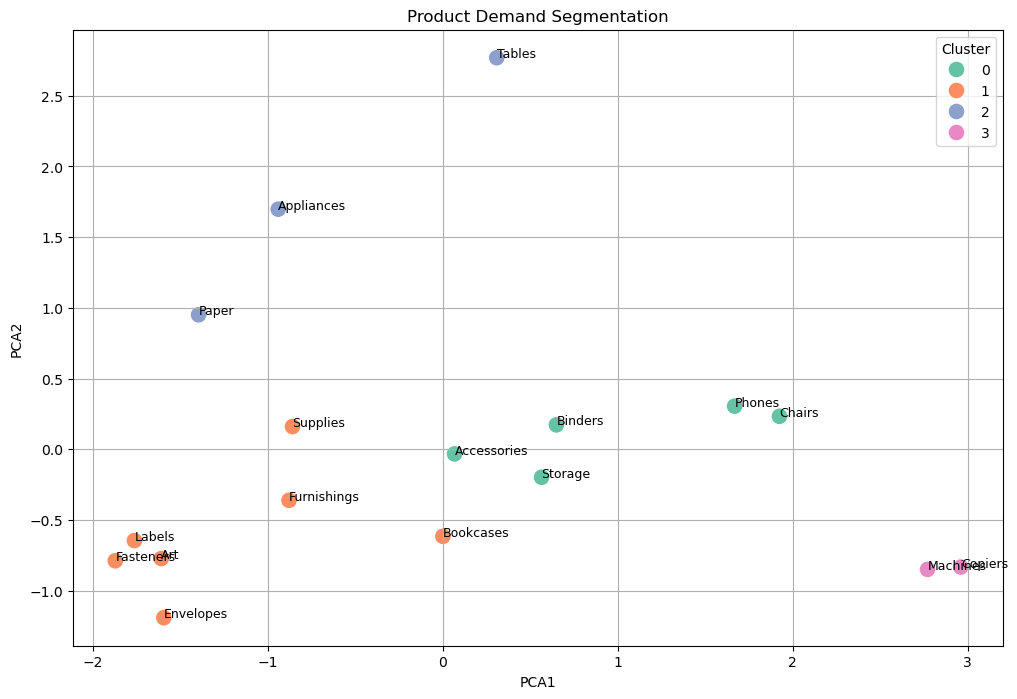

In [395]:
plt.figure(figsize=(12,8))

sns.scatterplot(

    data=product_data,

    x="PCA1",

    y="PCA2",

    hue="Cluster",

    palette="Set2",

    s=150

)

for i in range(len(product_data)):

    plt.text(

        product_data["PCA1"].iloc[i],

        product_data["PCA2"].iloc[i],

        product_data["Sub-Category"].iloc[i],

        fontsize=9

    )

plt.title("Product Demand Segmentation")

plt.grid(True)

plt.show()

In [397]:
cluster_map = {

    0:"High Volume Stable Demand",

    1:"Growing Demand",

    2:"Low Volume High Volatility",

    3:"Declining Demand"

}

product_data["Cluster Name"] = product_data["Cluster"].map(cluster_map)

In [399]:
product_data[

    [

        "Sub-Category",

        "Cluster",

        "Cluster Name"

    ]

]

,Sub-Category,Cluster,Cluster Name
0,Accessories,0,High Volume Stable Demand
1,Appliances,2,Low Volume High Volatility
2,Art,1,Growing Demand
3,Binders,0,High Volume Stable Demand
4,Bookcases,1,Growing Demand
5,Chairs,0,High Volume Stable Demand
6,Copiers,3,Declining Demand
7,Envelopes,1,Growing Demand
8,Fasteners,1,Growing Demand
9,Furnishings,1,Growing Demand


In [401]:
product_data["Cluster Name"].value_counts()

Cluster Name
Growing Demand                7
High Volume Stable Demand     5
Low Volume High Volatility    3
Declining Demand              2
Name: count, dtype: int64

In [403]:
product_data.to_csv(

    "Product_Demand_Segmentation.csv",

    index=False

)

## Inventory Strategies

### High Volume Stable Demand
Inventory should remain high since there is stable demand.

### Rising Demand
Incrementally increase inventory to meet rising demand.

### Low Volume Highly Variable Demand
Moderate inventory level should be kept with constant checking of demand.

### Falling Demand
Inventory should be decreased due to falling demand.

## Conclusion

K-Means clustering segmented products into four demand groups using Total Sales, Average Order Value, Sales Volatility, and Growth Rate.

The segmentation helps businesses identify products with stable demand, increasing demand, highly volatile demand, and declining demand. These insights support better inventory planning and stock management.